In [1]:
import os
import sys

# Add the parent directory to the system path
sys.path.append("../")
sys.path.append("../synthoseis")

In [2]:
import synthoseis.main as mn 
import numpy as np
import json
import pprint as pp
import matplotlib.pyplot as plt

In [ ]:
rock_model = json.load(open('../config/example.json', 'r'))
pp.pprint(rock_model)

{'bandwidth_high': [20.0, 35.0],
 'bandwidth_low': [3.0, 6.0],
 'bandwidth_ord': 4,
 'basin_floor_fans': False,
 'broadband_qc_volume': False,
 'closure_types': ['simple', 'faulted', 'onlap'],
 'cube_shape': [100, 100, 1250],
 'digi': 4,
 'dip_factor_max': 2,
 'extra_qc_plots': True,
 'incident_angles': [7, 15, 24],
 'include_channels': False,
 'include_salt': True,
 'infill_factor': 10,
 'initial_layer_stdev': [7.0, 25.0],
 'max_column_height': [150.0, 150.0],
 'max_number_faults': 6,
 'min_closure_voxels_faulted': 2500,
 'min_closure_voxels_onlap': 500,
 'min_closure_voxels_simple': 500,
 'min_number_faults': 1,
 'model_qc_volumes': True,
 'multiprocess_bp': True,
 'pad_samples': 10,
 'partial_voxels': True,
 'project': 'example',
 'project_folder': '../data/synthetic_data/run',
 'sand_layer_fraction': {'max': 0.25, 'min': 0.05},
 'sand_layer_thickness': 2,
 'seabed_min_depth': [20, 50],
 'signal_to_noise_ratio_db': [7.5, 12.5, 17.5],
 'thickness_max': 12,
 'thickness_min': 2,
 'vari

: 

: 

In [3]:
from util.filehandler import load_gp_model, load_gp_grid_params, save_gp_grid_params
from util.gaussian_processes import sample_gp_grid
shale_dict = load_gp_model('../data/models/shale_pl_vp_vs.pth', device='cuda')
save_gp_grid_params(shale_dict, '../data/grids/shale_pl_vp_vs.npz', depth_min = 1250, depth_max = 4200, log_transform = True)

/home/spaceswimmer/Documents/nnseismic/synthoseis/.venv/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Saved GP grid params to ../data/grids/shale_pl_vp_vs.npz (142.7 MB)
  Depth range: 1250 - 4200, step 1.0 (2951 points)
  Num tasks: 3
  Note: Used jitter=1.00e-03 for numerical stability


In [3]:
from util.filehandler import load_gp_model, save_gp_grid_params
brine_dict = load_gp_model('../data/models/brine_pl_vp_vs.pth', device='cuda')
save_gp_grid_params(brine_dict, '../data/grids/brine_pl_vp_vs.npz', depth_min = 1250, depth_max = 4200, log_transform = True)

/home/spaceswimmer/Documents/nnseismic/synthoseis/.venv/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Saved GP grid params to ../data/grids/brine_pl_vp_vs.npz (143.2 MB)
  Depth range: 1250 - 4200, step 1.0 (2951 points)
  Num tasks: 3
  Note: Used jitter=1.00e-03 for numerical stability


In [3]:
from util.filehandler import load_gp_model, save_gp_grid_params
oil_dict = load_gp_model('../data/models/oil_pl_vp_vs.pth', device='cuda')
save_gp_grid_params(oil_dict, '../data/grids/oil_pl_vp_vs.npz', depth_min = 1250, depth_max = 4200, log_transform = True)

/home/spaceswimmer/Documents/nnseismic/synthoseis/.venv/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Saved GP grid params to ../data/grids/oil_pl_vp_vs.npz (140.7 MB)
  Depth range: 1250 - 4200, step 1.0 (2951 points)
  Num tasks: 3
  Note: Used jitter=1.00e-02 for numerical stability


In [4]:
from util.filehandler import load_gp_model, save_gp_grid_params
gas_dict = load_gp_model('../data/models/gas_pl_vp.pth', device='cuda')
save_gp_grid_params(gas_dict, '../data/grids/gas_pl_vp.npz', depth_min = 1250, depth_max = 4200, log_transform = True)

/home/spaceswimmer/Documents/nnseismic/synthoseis/.venv/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Saved GP grid params to ../data/grids/gas_pl_vp.npz (61.4 MB)
  Depth range: 1250 - 4200, step 1.0 (2951 points)
  Num tasks: 2


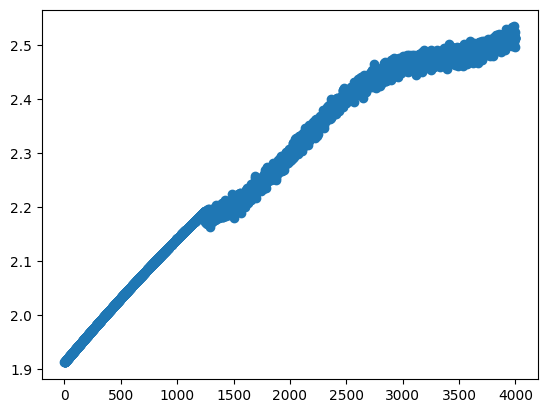

In [ ]:
from rockphysics.rpm_tagilsk import RPMTagilsk
test_class = RPMTagilsk('lala')
z = np.arange(0, 4000, 1)
test_values = test_class.calc_gas_sand_properties(z, z, z)
plt.scatter(z, test_values.rho)


In [ ]:
mn.build_model(user_json='../config/tagilsk1.json', run_id=5)

No coherent noise will be inserted
Salt will be NOT be inserted.

Model folder: /home/spaceswimmer/Documents/nnseismic/data/synthetic_data/run/seismic__2026.22998285_5
Creating directory: /home/spaceswimmer/Documents/nnseismic/data/synthetic_data/run/seismic__2026.22998285_5
Creating directory: /home/spaceswimmer/Documents/nnseismic/data/synthetic_data/temp/temp_folder__2026.22998285_5

Keyfile created at /home/spaceswimmer/Documents/nnseismic/data/synthetic_data/run/seismic__2026.22998285_5/seismicCube_2026.22998285.key
self.cfg.num_lyr_lut =  20000
onlap_layer_list =  [  7 128 139 150]
Number of onlapping flags: 4
 ... horizon number for first onlap episode = 7
 ... number of channelFlags: 0
 ... horizon number for first channel episode: 0
	Indices for shallowest point in cube: 99, 0
Building random depth map at base of model
azi, dip, dipping_plane min/mean/max = 73.96931496571324, 0.2816509502467973, 0.00, 0.43, 0.85
current_depth_map min/mean/max = 9963.60, 10135.22, 10325.51
thic

  0%|          | 0/3 [00:00<?, ?it/s]



 ... inserting fault 0 with throw 5.75
   ... fault ellipsoid semi-axes (a, b, c): 115.44, 184.20, 10293.33
   ... fault ellipsoid origin (x, y, z): 111.77, -105.52, -1919.58
   ... tilt_pct: 38.12
   ...z for bottom of ellipsoid at depth (samples) = -19758847.0
   ...shape of output_cube = (100, 100, 2010)
   ...infill_factor, pad_samples = 5, 10
   ...shear_zone_width (samples) = 1.5
   ...gouge_pctile (percent*100) = 57.048459070053774
   .... output_cube.shape = (100, 100, 2010)
   .... (np.arange(output_cube.shape[2])*infill_factor).shape = (2010,)
   ... Computing fault middle to hang max displacement function
    ... x idx for max displacement  =  75
    ... y idx for max displacement  =  24
    ... z idx for max displacement  =  980
    ... ellipsoid value  =  0.0
    ... Computing fault depth at max displacement
    ... depth at max displacement  = 980
    ... This fault has 13.8% of downthrown samples
   ... Taper fault so it doesn't reach seabed
    ... Sea floor max = 160

 33%|███▎      | 1/3 [00:08<00:16,  8.47s/it]

   ...hockey_sticks = , [0]


 ... inserting fault 1 with throw 7.45
   ... fault ellipsoid semi-axes (a, b, c): 388.81, 247.38, 9510.25
   ... fault ellipsoid origin (x, y, z): -180.26, 297.15, -1270.75
   ... tilt_pct: 14.38
   ...z for bottom of ellipsoid at depth (samples) = -12085099.0
   ...shape of output_cube = (100, 100, 2010)
   ...infill_factor, pad_samples = 5, 10
   ...shear_zone_width (samples) = 1.5
   ...gouge_pctile (percent*100) = 50.223857815335535
   .... output_cube.shape = (100, 100, 2010)
   .... (np.arange(output_cube.shape[2])*infill_factor).shape = (2010,)
   ... Computing fault middle to hang max displacement function
    ... x idx for max displacement  =  8
    ... y idx for max displacement  =  95
    ... z idx for max displacement  =  402
    ... ellipsoid value  =  0.0
    ... Computing fault depth at max displacement
    ... depth at max displacement  = 402
    ... This fault has  0.6% of downthrown samples
   ... Taper fault so it doesn't reach seabed
 

...

/home/spaceswimmer/Documents/nnseismic/src/../synthoseis/datagenerator/Closures.py:3282: UserWarning:

Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?



     ...+++... number of nan's in depth_maps_gaps before insertClosureLabels3D ...+++... (0,)
     ...+++... number of nan's in depth_maps_gaps after insertClosureLabels3D ...+++... (72634,)
     ...+++... number of nan's in depth_maps after insertClosureLabels3D ...+++... (0,)
     ...+++... number of closure voxels in self.closure_segments ...+++... (11240,)
labels_clean succeeded.
 labels.min:0, labels.max: 9
 labels_clean min:0, labels_clean max: 4
 Inside parse_label_values_and_counts
Label: 1, label_values: 1, label_counts: 4230
Label: 2, label_values: 2, label_counts: 2380
Label: 3, label_values: 3, label_counts: 607
Label: 4, label_values: 4, label_counts: 1260
labels_clean succeeded.
 labels.min:0, labels.max: 367
 labels_clean min:0, labels_clean max: 299
 Inside parse_label_values_and_counts
Label: 1, label_values: 15, label_counts: 21244
Label: 2, label_values: 37, label_counts: 122153
Label: 3, label_values: 45, label_counts: 21936
Label: 4, label_values: 77, label_counts:

/home/spaceswimmer/Documents/nnseismic/synthoseis/.venv/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning:

Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations




 ... layer number = 1
 ... sum_net (min,mean,max) = (0.0, 0.0, 0.0)

 ... layer number = 1
 ... (shale, brine, oil, gas) voxel_counts = (3095, 0, 0, 0)
 ... shale_count = brine+oil+gas? False
*********************


*********************
 ... layer number = 2
 ... n2g (min,mean,max) = (0.0,0.0,0.0,)
 .... Layer 2: voxel_count = 69093
 .... Layer 2: delta_z_layer = 0
 .... Layer 2: z-range (m): 144, 940
 ... shale: (delta_z_rho, delta_z_vp, delta_z_vs) = (0, 0, 0)
 ... shale: i = 50.34255279116553
 ... shale: k = 130.495679736008
 ... shale: _k = 130.495679736008


/home/spaceswimmer/Documents/nnseismic/synthoseis/.venv/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning:

Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations



In [38]:
seismic = np.load('../data/synthetic_data/temp/test_test_mode_/seismic__2025.96192465_2/seismicCubes_cumsum__0_degrees_normalized_2025.96192465.npy')
geology = np.load('../data/synthetic_data/temp/test_test_mode_/seismic__2025.96192465_2/qc_volume_vp_2025.96192465.npy')
print(geology.shape)

(100, 100, 1260)


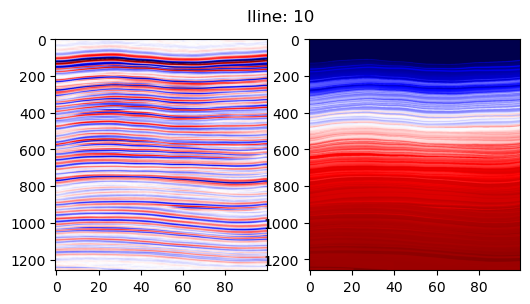

In [39]:
fig, axs = plt.subplots(1,2, figsize=(6,3))
iline = 10


fig.suptitle(f'Iline: {iline}')
axs[0].imshow(seismic[iline,:,:].T, cmap=plt.cm.seismic, aspect='auto')
axs[1].imshow(geology[iline,...].T, cmap=plt.cm.seismic, aspect='auto')
plt.show()